In [ ]:
# Robot Vision System

In [ ]:
## 1. Install Libraries

# Install YOLO
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00


In [ ]:
## 2. Import Libraries
# Import the YOLO model
from ultralytics import YOLO

# OpenCV for image processing
import cv2

# Display images inside Colab
import matplotlib.pyplot as plt

# Save detections in JSON format
import json

# Numerical operations
import numpy as np

print("✅ All libraries imported successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All libraries imported successfully!


In [ ]:
## 3. Load YOLO Model
# Load the pretrained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

print("✅ YOLO model loaded successfully!")

print(model.names)

✅ YOLO model loaded successfully!
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboa

In [ ]:
## 4. Upload Image
from google.colab import files

# Upload an image from your computer
uploaded = files.upload()

Saving green-farmhouse-kitchen-65a6bfa07e112.avif to green-farmhouse-kitchen-65a6bfa07e112.avif



image 1/1 /content/green-farmhouse-kitchen-65a6bfa07e112.avif: 640x640 11 bowls, 1 chair, 4 potted plants, 2 ovens, 1 book, 1 vase, 229.8ms
Speed: 4.3ms preprocess, 229.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
✅ Object detection completed!


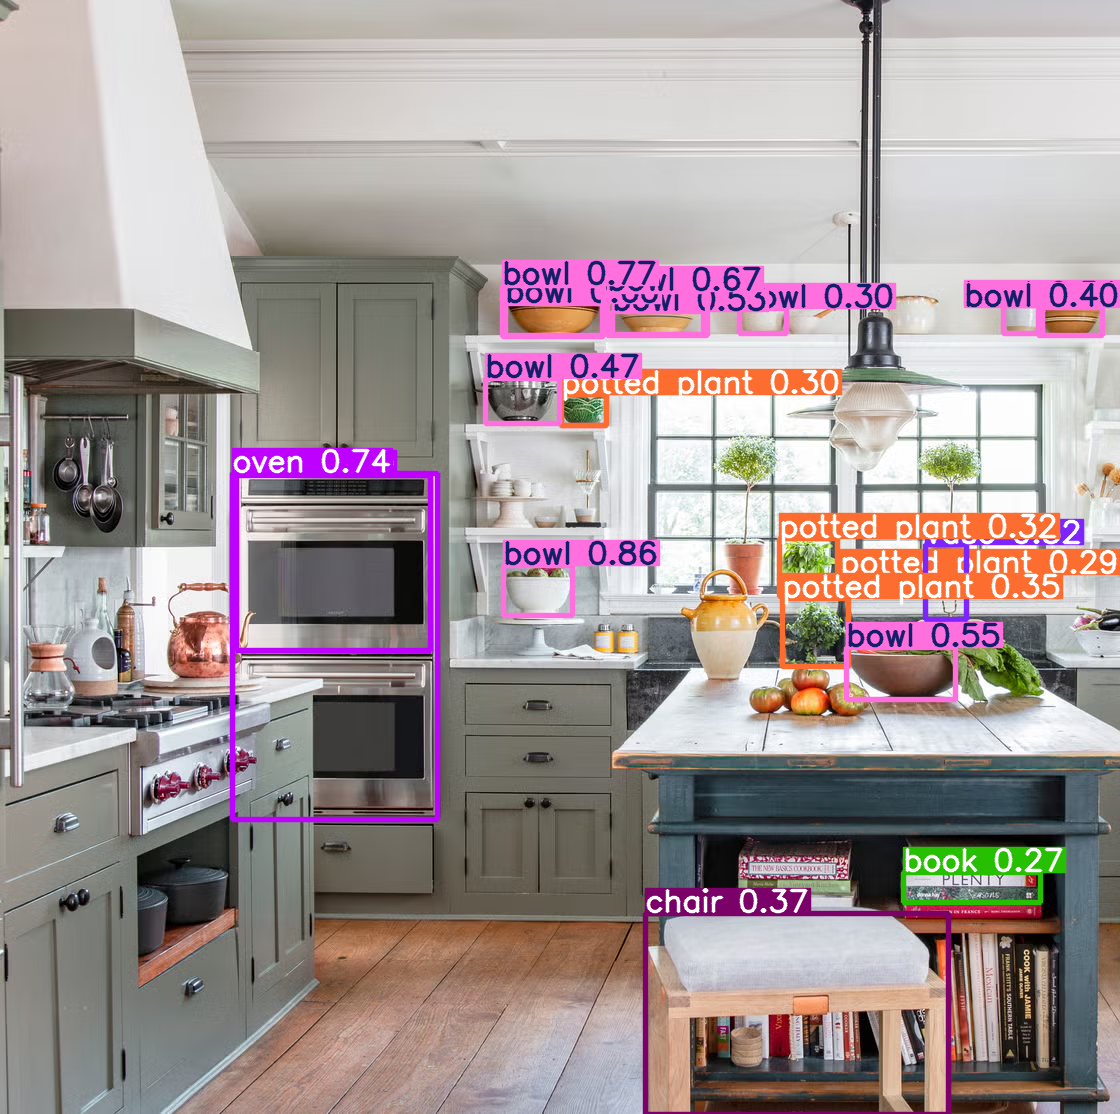

✅ Image saved successfully!
Number of detections: 20


In [ ]:
## 5. Detect Objects

results = model("green-farmhouse-kitchen-65a6bfa07e112.avif")

print("✅ Object detection completed!")

results[0].show()

results[0].save(filename="detected_kitchen.jpg")

print("✅ Image saved successfully!")

print("Number of detections:", len(results[0].boxes))

In [ ]:
## 6. Visualize Results
## 7. Extract Detection Information

detections = []

CONFIDENCE_THRESHOLD = 0.50

for box in results[0].boxes:

    class_id = int(box.cls[0])
    object_name = model.names[class_id]
    confidence = float(box.conf[0])

    # Ignore weak detections
    if confidence < CONFIDENCE_THRESHOLD:
        continue

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    detections.append({
        "object": object_name,
        "confidence": round(confidence, 2),
        "bounding_box": {
            "x1": round(x1, 2),
            "y1": round(y1, 2),
            "x2": round(x2, 2),
            "y2": round(y2, 2)
        }
    })

print(detections)

[{'object': 'bowl', 'confidence': 0.86, 'bounding_box': {'x1': 503.97, 'y1': 565.72, 'x2': 572.77, 'y2': 615.29}}, {'object': 'bowl', 'confidence': 0.77, 'bounding_box': {'x1': 502.18, 'y1': 285.99, 'x2': 603.29, 'y2': 336.76}}, {'object': 'oven', 'confidence': 0.74, 'bounding_box': {'x1': 232.83, 'y1': 473.25, 'x2': 437.82, 'y2': 819.47}}, {'object': 'bowl', 'confidence': 0.67, 'bounding_box': {'x1': 607.39, 'y1': 291.88, 'x2': 707.52, 'y2': 335.26}}, {'object': 'bowl', 'confidence': 0.6, 'bounding_box': {'x1': 505.72, 'y1': 303.04, 'x2': 602.42, 'y2': 335.66}}, {'object': 'bowl', 'confidence': 0.55, 'bounding_box': {'x1': 846.35, 'y1': 647.16, 'x2': 955.94, 'y2': 699.24}}, {'object': 'bowl', 'confidence': 0.53, 'bounding_box': {'x1': 612.45, 'y1': 311.27, 'x2': 703.26, 'y2': 334.13}}]


In [ ]:
## 7. Count Objects
from collections import Counter

# Count each detected object
object_counts = Counter([item["object"] for item in detections])

print("Object Counts")
print("-" * 30)

for obj, count in object_counts.items():
    print(f"{obj}: {count}")

print("-" * 30)
print(f"Total Objects Detected: {len(detections)}")

Object Counts
------------------------------
bowl: 6
oven: 1
------------------------------
Total Objects Detected: 7


In [ ]:
## 8. Export to JSON

# Save detections to a JSON file

with open("detections.json", "w") as f:
    json.dump(detections, f, indent=4)

print("✅ detections.json has been created successfully!")

with open("detections.json", "r") as f:
    data = json.load(f)

print(data)

from google.colab import files

files.download("detections.json")




✅ detections.json has been created successfully!
[{'object': 'bowl', 'confidence': 0.86, 'bounding_box': {'x1': 503.97, 'y1': 565.72, 'x2': 572.77, 'y2': 615.29}}, {'object': 'bowl', 'confidence': 0.77, 'bounding_box': {'x1': 502.18, 'y1': 285.99, 'x2': 603.29, 'y2': 336.76}}, {'object': 'oven', 'confidence': 0.74, 'bounding_box': {'x1': 232.83, 'y1': 473.25, 'x2': 437.82, 'y2': 819.47}}, {'object': 'bowl', 'confidence': 0.67, 'bounding_box': {'x1': 607.39, 'y1': 291.88, 'x2': 707.52, 'y2': 335.26}}, {'object': 'bowl', 'confidence': 0.6, 'bounding_box': {'x1': 505.72, 'y1': 303.04, 'x2': 602.42, 'y2': 335.66}}, {'object': 'bowl', 'confidence': 0.55, 'bounding_box': {'x1': 846.35, 'y1': 647.16, 'x2': 955.94, 'y2': 699.24}}, {'object': 'bowl', 'confidence': 0.53, 'bounding_box': {'x1': 612.45, 'y1': 311.27, 'x2': 703.26, 'y2': 334.13}}]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from collections import Counter

# Count detected objects
object_counts = Counter([item["object"] for item in detections])

# Find highest confidence detection
best_detection = max(detections, key=lambda x: x["confidence"])

# Calculate average confidence
average_confidence = sum(item["confidence"] for item in detections) / len(detections)

print("=" * 50)
print("           ROBOT VISION REPORT")
print("=" * 50)

print(f"\nTotal Objects Detected : {len(detections)}")

print("\nObject Summary:")
for obj, count in object_counts.items():
    print(f"  • {obj}: {count}")

print("\nHighest Confidence Detection:")
print(f"  Object      : {best_detection['object']}")
print(f"  Confidence  : {best_detection['confidence']:.2f}")

print(f"\nAverage Confidence : {average_confidence:.2f}")

print("\nSystem Status : SUCCESS")
print("Scene analyzed successfully.")
print("=" * 50)

           ROBOT VISION REPORT

Total Objects Detected : 7

Object Summary:
  • bowl: 6
  • oven: 1

Highest Confidence Detection:
  Object      : bowl
  Confidence  : 0.86

Average Confidence : 0.67

System Status : SUCCESS
Scene analyzed successfully.
